In [11]:
import pandas as pd
import os

# Write the folder name only once
data_folder = "vol_1_rsi_1_bb_1_ma_1"

# Build paths from that
csv_path = os.path.join(data_folder, "labels.csv")

# Load csv
df = pd.read_csv(csv_path)

# Convert dates
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

# Use end_date as the observation date for splitting
df["date"] = df["end_date"]

print(df.head())
print(df.info())
print(df["label"].value_counts())

                                          image_path ticker start_date  \
0  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-01-30_to_...   AAPL 2020-01-30   
1  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-02-06_to_...   AAPL 2020-02-06   
2  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-02-13_to_...   AAPL 2020-02-13   
3  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-02-21_to_...   AAPL 2020-02-21   
4  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-02-28_to_...   AAPL 2020-02-28   

    end_date  close_now  close_future  label       date  
0 2020-02-05     321.45        327.20      1 2020-02-05  
1 2020-02-12     327.20        320.30      0 2020-02-12  
2 2020-02-20     320.30        273.52      0 2020-02-20  
3 2020-02-27     273.52        292.92      1 2020-02-27  
4 2020-03-05     292.92        248.23      0 2020-03-05  
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   image_path 

Tjekker at Billederne eksistere og fjerner rækker hvor billeder ikke eksisterer

In [12]:
import os

df["file_exists"] = df["image_path"].apply(os.path.exists)

print(df["file_exists"].value_counts())

# Keep only rows where the image exists
df = df[df["file_exists"]].copy()

file_exists
True    18
Name: count, dtype: int64


Sorterer data efter tid, så rækker der tilhører samme Ticker/firma ikke længere kommer efter hinanden. Det er fordi man i Finans verden gerne vil bruge gammel data til at forudsige ny data. Altså skal rækker med samme Ticker/firma ikke ligge sammen. Derimod skal den træne gammel data fra alle de forskellige Firmaer.

In [13]:
df = df.sort_values("date").reset_index(drop=True)

Step 5: Split by unique dates, not by rows

This is important. Since many companies share the same dates, it is better to split by the set of unique dates.

In [14]:
unique_dates = sorted(df["date"].unique())

n_dates = len(unique_dates)
train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (14, 9)
Val shape: (2, 9)
Test shape: (2, 9)


In [15]:
print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

print("\nNumber of tickers:")
print("Train:", train_df["ticker"].nunique())
print("Val:  ", val_df["ticker"].nunique())
print("Test: ", test_df["ticker"].nunique())

print("\nLabel balance:")
print("Train:\n", train_df["label"].value_counts(normalize=True))
print("Val:\n", val_df["label"].value_counts(normalize=True))
print("Test:\n", test_df["label"].value_counts(normalize=True))


Date ranges:
Train: 2020-02-05 00:00:00 to 2020-03-05 00:00:00
Val:   2020-03-12 00:00:00 to 2020-03-12 00:00:00
Test:  2020-03-19 00:00:00 to 2020-03-26 00:00:00

Number of tickers:
Train: 3
Val:   2
Test:  1

Label balance:
Train:
 label
1    0.5
0    0.5
Name: proportion, dtype: float64
Val:
 label
0    1.0
Name: proportion, dtype: float64
Test:
 label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [16]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

In [17]:
import sys
print(sys.executable)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


Image batch shape: torch.Size([14, 3, 224, 224])
Label batch shape: torch.Size([14])
First 10 labels: tensor([1, 0, 1, 0, 0, 1, 1, 1, 0, 0])


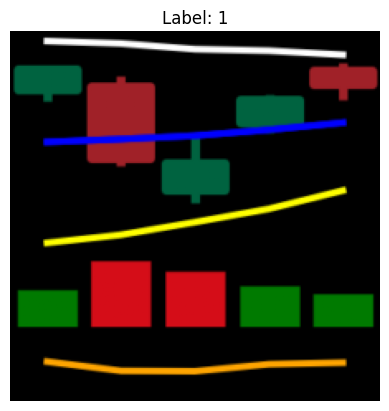

In [18]:
import pandas as pd
from PIL import Image
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

class StockImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = StockImageDataset(train_df, transform=basic_transform)
val_dataset   = StockImageDataset(val_df, transform=basic_transform)
test_dataset  = StockImageDataset(test_df, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Test one batch
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

# Show one example image
image, label = train_dataset[0]
img_np = image.permute(1, 2, 0).numpy()

plt.imshow(img_np)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Hvis PyTorch bruger CPU i stedet for Nvidia GPU er det fordi du har installeret en CPU version af PyTorch. Så kan man køre følgende kommandoer for at få CUDA version med PyTorch
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [19]:
import torch
import sys

print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Python: c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
Torch CUDA version: 12.6
GPU count: 1
GPU name: NVIDIA GeForce RTX 4070


In [21]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 56 -> 28
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_val_loss = float("inf")

model_save_path = os.path.join(data_folder, "best_cnn.pth")


for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_save_path)
        print("  Saved best model.")

Using device: cuda
Epoch 1/10
  Train loss: 0.6934 | Train acc: 0.4286
  Val   loss: 0.6635 | Val   acc: 1.0000
  Saved best model.
Epoch 2/10
  Train loss: 0.6556 | Train acc: 0.6429
  Val   loss: 1.4612 | Val   acc: 0.0000
Epoch 3/10
  Train loss: 0.5175 | Train acc: 0.7143
  Val   loss: 0.5433 | Val   acc: 1.0000
  Saved best model.
Epoch 4/10
  Train loss: 0.5754 | Train acc: 0.5714
  Val   loss: 0.9820 | Val   acc: 0.0000
Epoch 5/10
  Train loss: 0.3992 | Train acc: 0.8571
  Val   loss: 2.1607 | Val   acc: 0.0000
Epoch 6/10
  Train loss: 0.3683 | Train acc: 0.7857
  Val   loss: 2.0201 | Val   acc: 0.0000
Epoch 7/10
  Train loss: 0.3441 | Train acc: 0.9286
  Val   loss: 1.3386 | Val   acc: 0.0000
Epoch 8/10
  Train loss: 0.1437 | Train acc: 1.0000
  Val   loss: 1.4256 | Val   acc: 0.0000
Epoch 9/10
  Train loss: 0.2291 | Train acc: 0.9286
  Val   loss: 1.9819 | Val   acc: 0.0000
Epoch 10/10
  Train loss: 0.0825 | Train acc: 0.9286
  Val   loss: 2.6623 | Val   acc: 0.0000


In [22]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
model_save_path = os.path.join(data_folder, "best_cnn.pth")

model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc:  {test_acc:.4f}")

Test loss: 0.5502
Test acc:  0.5000
